# Fig Experiment: Fit Filtered Prev Violation

Fit model with binary violation history and interaction with stimuli


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

from violmulti.experiments.experiment import load_experiment
from violmulti.experiments.experiment_sigma_sweep import ExperimentSigmaSweep
from violmulti.models.multiclass_logistic_regression import MultiClassLogisticRegression
from violmulti.visualizations.model_visualizer import ModelVisualizer
from violmulti.features.design_matrix_generator_PWM import *

from violmulti.visualizations.model_visualizer import *

from violmulti.data import ANIMAL_IDS
from violmulti.experiments import STANDARD_SIGMAS
import config as c

sns.set_context("talk")
%load_ext autoreload
%autoreload 2

In [4]:
dmg_config = {
    "session": lambda df: (copy(df.session)),
    "bias": lambda df: (add_bias_column(df)),
    "s_a": lambda df: (standardize(df.s_a)),
    "sa_x_prev_viol": lambda df: (
        stim_filt_viol_intrx(df, "s_a", get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
    ),
    "s_b": lambda df: (standardize(df.s_b)),
    "sb_x_prev_viol": lambda df: (
    stim_filt_viol_intrx(df, "s_b", get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
    ),
    "filt_prev_violation": lambda df: (
        filtered_prev_viol(df, get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
    ),
    "prev_stim_avg": lambda df: (prev_avg_stim(df, mask_prev_violation=False)),
    "prev_correct": lambda df: (prev_correct_side(df)),
    "prev_choice": lambda df: (prev_choice(df)),
    "labels": multi_choice_labels(),
}

model_config = {
    "prev_viol_filtered_itrx": {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": dmg_config,
    }
}


params = {
    "animals": ANIMAL_IDS,
    "data_type": "new_trained_cleaned",
    "sigmas": STANDARD_SIGMAS,
    "random_state": 47,
    "eval_train": True,
    "null_mode": "multi",
    "model_config": model_config,
}
save_name = "2025_07_22_fig4_fit_filtered_prev_viol_stim_intrx_n_rs47.pkl"

In [5]:
experiment = ExperimentSigmaSweep(params)
experiment.run()
experiment.save(save_name, file_path=c.MODEL_FITS_PATH)

Loading dataset type : new_trained_cleaned
DataLoader: Loading data type:  new_trained_cleaned  for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']

 >>>> evaluating animal W051 <<<<

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.07 *****
Optimization terminated successfully.
         Current function value: 64525.047188
         Iterations: 31
         Function evaluations: 47
         Gradient evaluations: 47

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.13 *****
         Current function value: 64238.327188
         Iterations: 28
         Function evaluations: 59
         Gradient evaluations: 48

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.25 *****
         Current function value: 64146.412374
         Iterations: 28
         Function evaluations: 57
         Gradient evaluations: 46

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.5 **

### Visualize


In [ ]:
exp = load_experiment(save_name, save_path=c.MODEL_FITS_PATH)
mv = ModelVisualizer(exp)

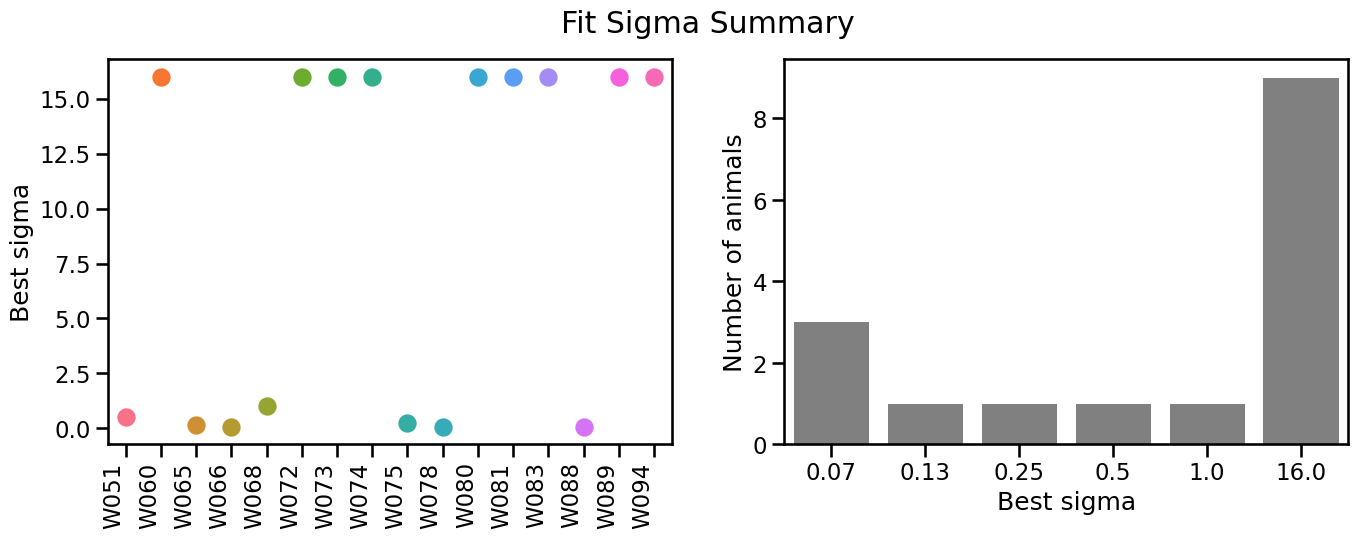

In [ ]:
mv.plot_sigma_summary()

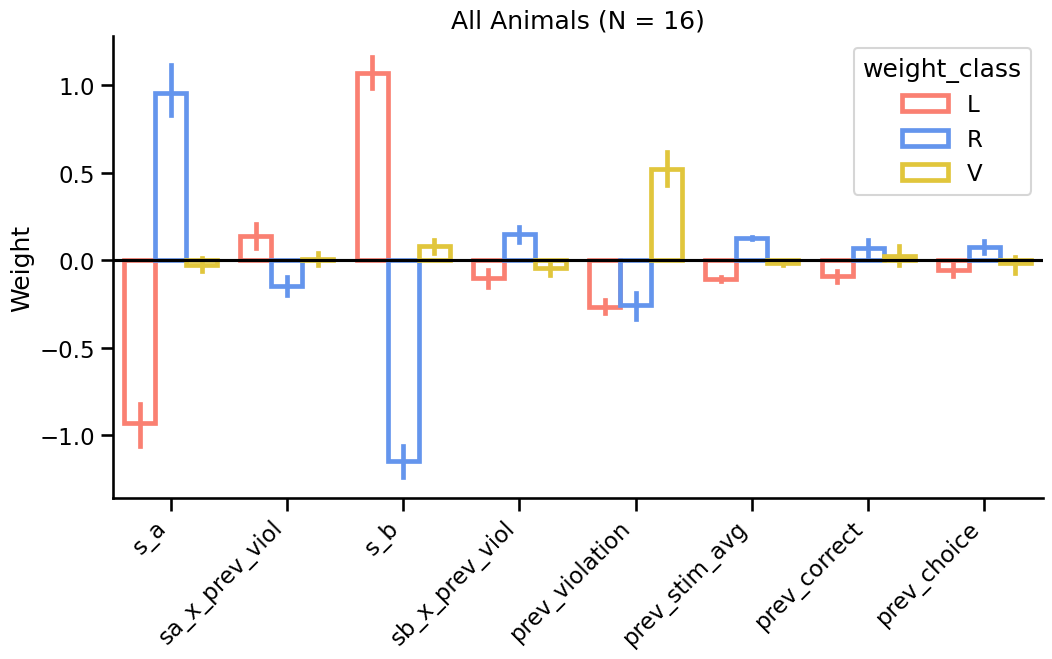

In [ ]:
mv.plot_weights_summary(palette=c.MULTI_CHOICE_PAL)

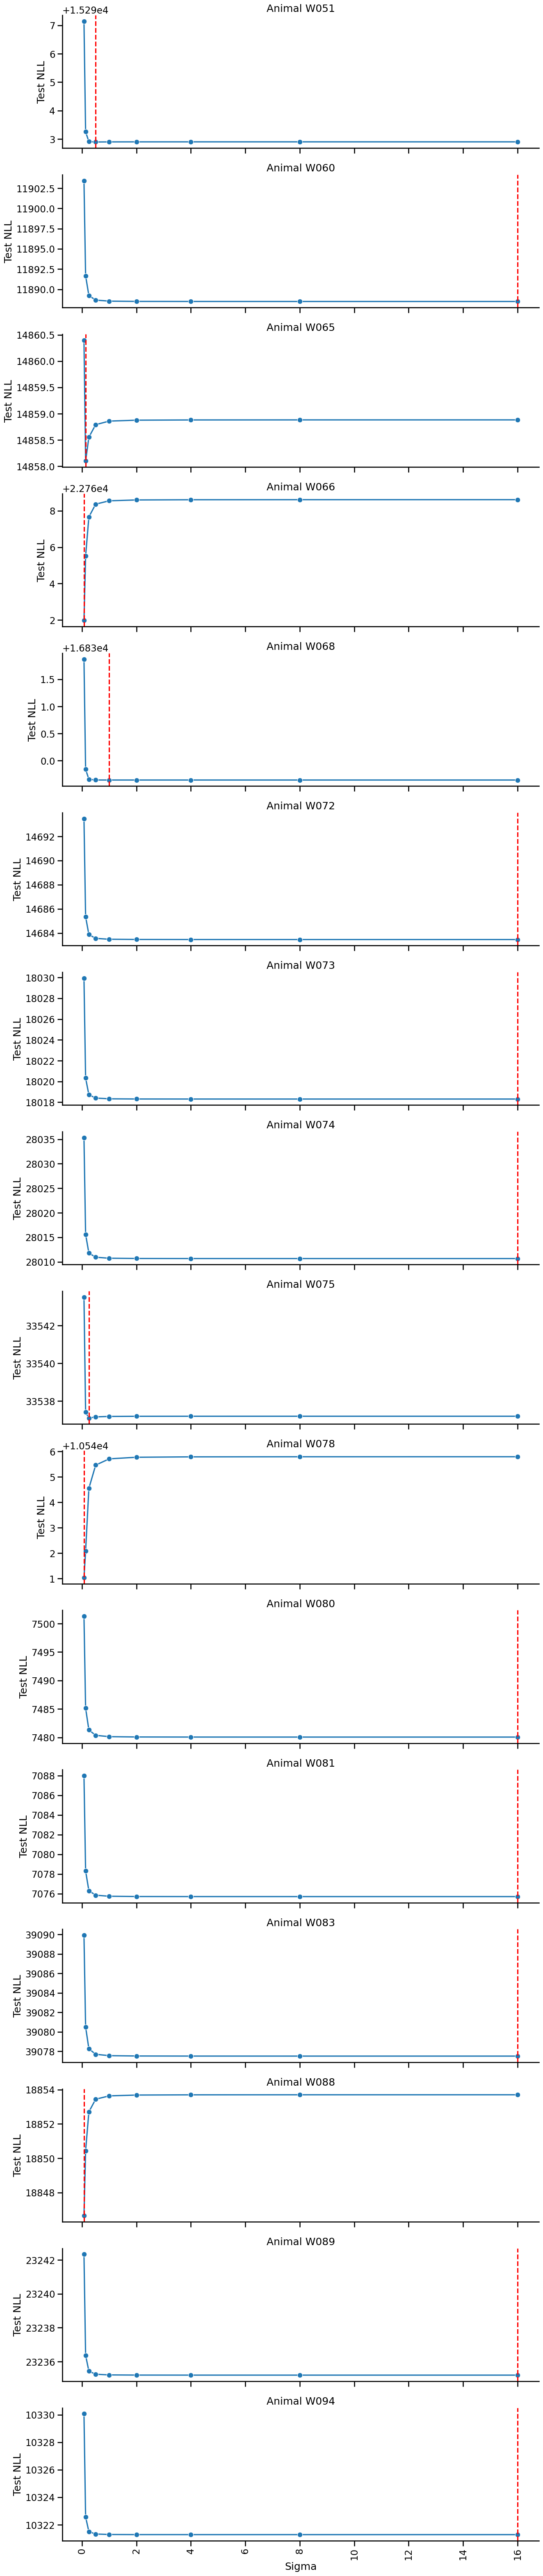

In [ ]:
mv.plot_nll_over_sigmas_by_animal()

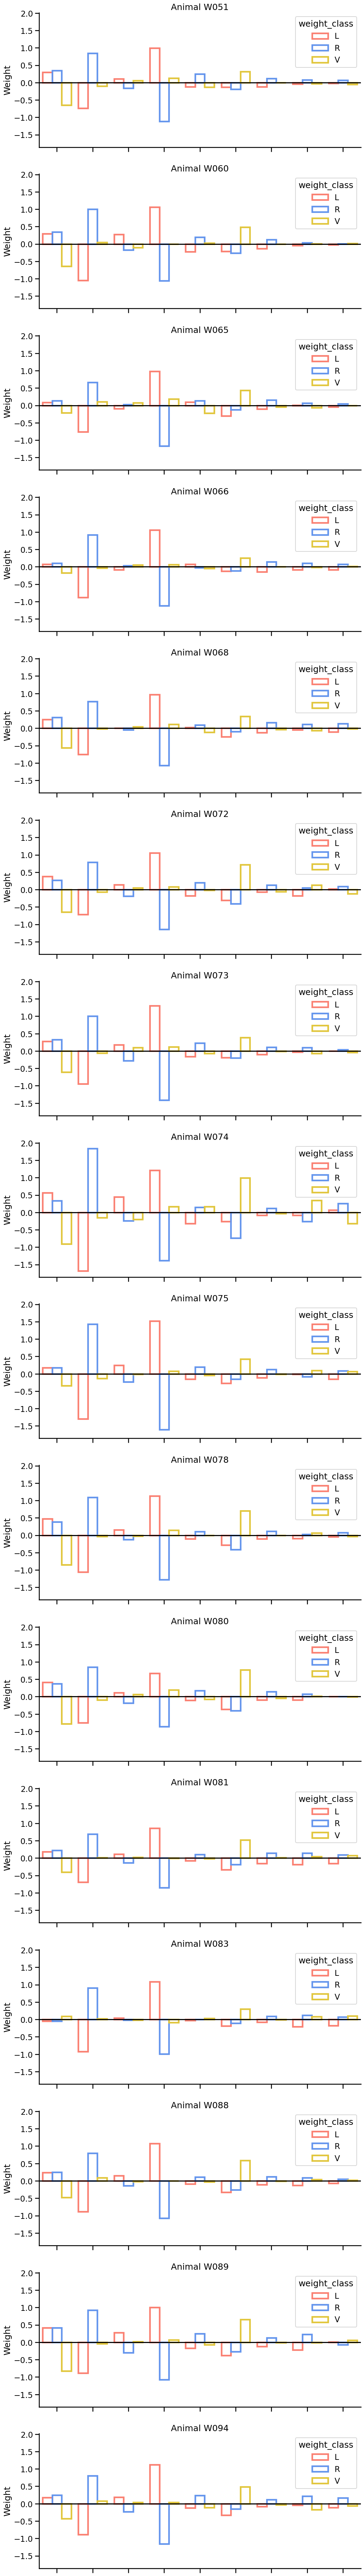

In [ ]:
mv.plot_weights_by_animal(palette=c.MULTI_CHOICE_PAL)